#### Problem Statement : 
#### You are tasked with creating a neural network model to predict whether a student will pass or fail an exam based on two features:hours studied and previous exam scores. The dataset should contains information on hours studied and previous exam scores for a group of students , along with their exam outcomes (pass or fail).

In [1]:
# Install TensorFlow (Neural Network library)
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Install Keras separately
!pip install keras

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


In [4]:
# step 1 : Import Required Libraries 

import pandas as pd      # for data loading and handling
import numpy as np       # for numrical operations
import matplotlib.pyplot as plt # for plotting graphs
import seaborn as sns     # for attractive visualization 

from sklearn.model_selection import train_test_split        # for splitting data into train and test 
from sklearn.preprocessing import StandardScaler            # for feature scaling
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report  # for model evaluation

# Import TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential         # for building neural network model
from tensorflow.keras.layers import Dense              # for adding dense layers
from tensorflow.keras.optimizers import Adam           # for optimizer 

In [5]:
# Step 2 : Load dataset 
df = pd.read_csv("student_exam_data.csv")    # Read the CSV file 

# Display first 5 rows 
print("First 5 rows of dataset : ")
print(df.head())

First 5 rows of dataset : 
   Hours_Studied  Previous_Score  Result
0            1.0              35       0
1            2.0              40       0
2            1.5              38       0
3            3.0              45       0
4            2.5              42       0


In [6]:
# Step 3 : Data Cleaning & Understanding 

# check shape of dataset 
print("\nDataset Shape :",df.shape)

# check dataset information 
print("\nDataset Info : ")
print(df.info())

# check missing values 
print("\nMissing Values : ")
print(df.isnull().sum())

# Display statistical summary 
print("\nStatistical Summary : ")
print(df.describe())



Dataset Shape : (52, 3)

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Studied   52 non-null     float64
 1   Previous_Score  52 non-null     int64  
 2   Result          52 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB
None

Missing Values : 
Hours_Studied     0
Previous_Score    0
Result            0
dtype: int64

Statistical Summary : 
       Hours_Studied  Previous_Score     Result
count      52.000000       52.000000  52.000000
mean        5.582692       58.442308   0.538462
std         2.636079       14.668111   0.503382
min         1.000000       30.000000   0.000000
25%         3.425000       46.750000   0.000000
50%         5.650000       60.000000   1.000000
75%         7.850000       70.250000   1.000000
max        10.000000       85.000000   1.000000


In [7]:
import os

# Create folder if not exists
os.makedirs("images/Pass", exist_ok=True)

# Now save image
plt.savefig("images/Pass/Fail Distribution.png")
plt.show()

<Figure size 640x480 with 0 Axes>

<function matplotlib.pyplot.show(close=None, block=None)>

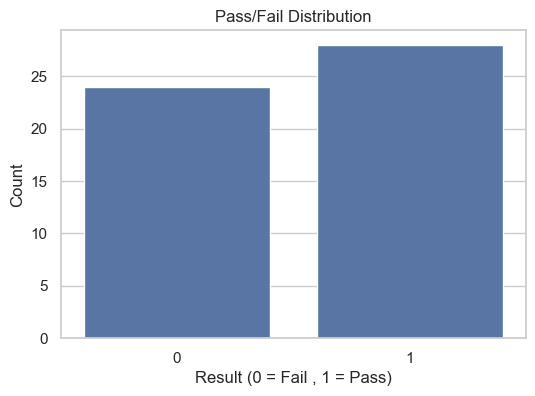

In [8]:
# Step 4 : Data Visualization 

# Set Plot style 
sns.set(style="whitegrid")

# Plot 1 : countplot for result 
plt.figure(figsize=(6,4))
sns.countplot(x="Result" , data=df)
plt.title("Pass/Fail Distribution")
plt.xlabel("Result (0 = Fail , 1 = Pass)")
plt.ylabel("Count")
plt.savefig("images/Pass/Fail Distribution.png")
plt.show 

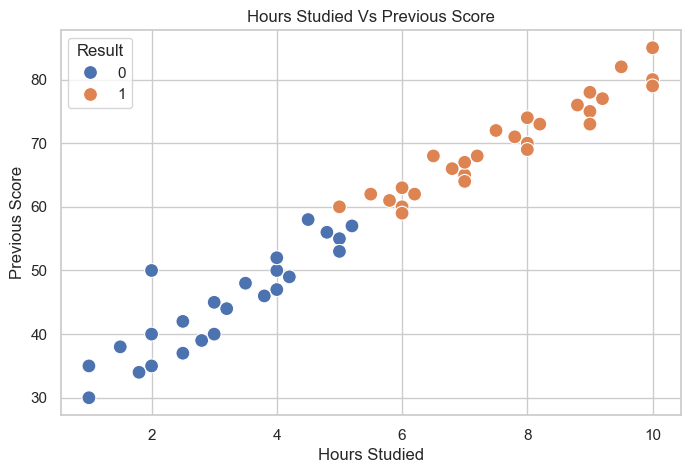

In [9]:
# Plot 2 : Scatter plot of Hours Studied Vs Previous Score 
plt.figure(figsize=(8,5))
sns.scatterplot(x="Hours_Studied" , y="Previous_Score" , hue="Result" , data=df , s=100)
plt.title("Hours Studied Vs Previous Score")
plt.xlabel("Hours Studied")
plt.ylabel("Previous Score")
plt.savefig("images/Hours Studied Vs Previous Score.png")
plt.show()

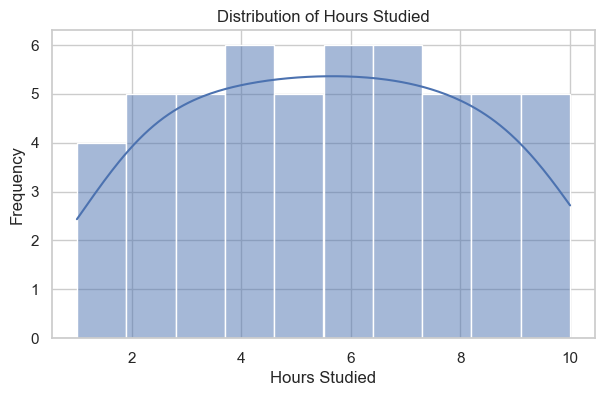

In [10]:
# Plot 3 : Histogram for Hours Studied 
plt.figure(figsize=(7,4))
sns.histplot(df["Hours_Studied"], kde=True , bins=10)
plt.title("Distribution of Hours Studied")
plt.xlabel("Hours Studied")
plt.ylabel("Frequency")
plt.savefig("images/Distribution of Hours Studied.png")
plt.show()

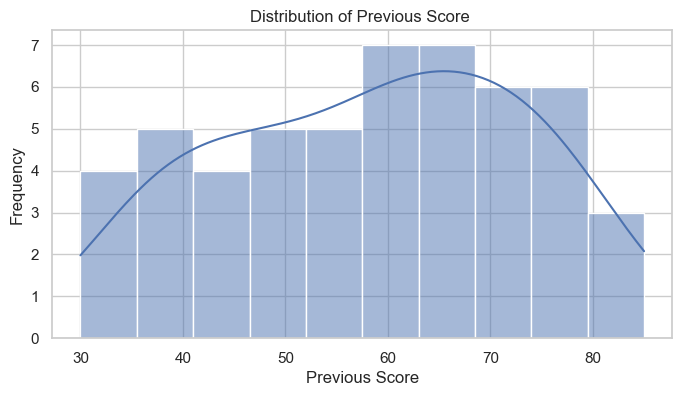

In [11]:
# Plot 4 : Histogram for Previous Score 
plt.figure(figsize=(8,4))
sns.histplot(df["Previous_Score"] , kde=True , bins = 10)
plt.title("Distribution of Previous Score ")
plt.xlabel("Previous Score")
plt.ylabel("Frequency")
plt.savefig("images/Distribution of Previous Score")
plt.show()

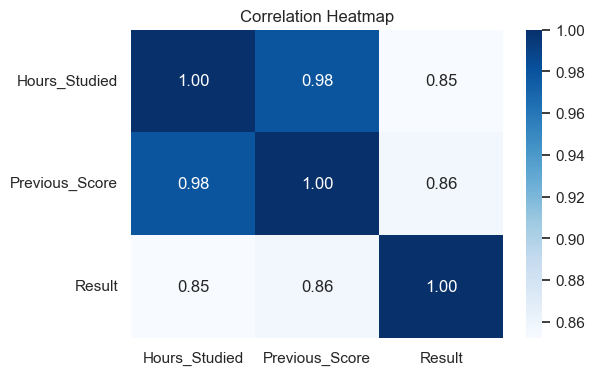

In [12]:
# Plot 5 : Correlation heatmap 
plt.figure(figsize=(6,4))
sns.heatmap(df.corr() , annot=True , cmap="Blues" , fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("images/Correlation Heatmap")
plt.show()

In [13]:
# Step 5 : Define features and target 

# Select input features 
X = df[["Hours_Studied" , "Previous_Score"]]

# Select target column
y = df["Result"]

In [14]:
# Step 6 : Train - test split

# Split dataset into training and testing data 
X_train , X_test , y_train , y_test = train_test_split(
    X,y, test_size=0.2 , random_state=42 , stratify=y
)

# Print Shapes 
print("\nTraining feature shape : " , X_train.shape)
print("\nTesting feature shape : " , X_test.shape)
print("\nTraining target shape : " , y_train.shape)
print("\nTraining target shape : " , y_test.shape)


Training feature shape :  (41, 2)

Testing feature shape :  (11, 2)

Training target shape :  (41,)

Training target shape :  (11,)


In [18]:
# Step 7 : Feature scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [19]:
# Step 8 : Build Neural Network Model

# Create sequential model 
model = Sequential()

# Add first hidden layer with 8 neurons and ReLU activation 
model.add(Dense(8 , activation="relu" , input_shape = (2,)))

#Add second hidden layer with 4 neurons and ReLU activation 
model.add(Dense(4 , activation="relu"))

# Add Output layer with 1 neuron and sigmoid activation 
model.add(Dense(1 , activation="sigmoid"))

# Compile the model 
model.compile(
    optimizer = Adam(learning_rate = 0.01),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

# Display model summary
print("\nModel Summary : ")
model.summary()


Model Summary : 


C:\Users\sagar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Step 9 : Train the model 

# Train the neural network
history = model.fit(
    X_train_scaled , y_train,
    epochs = 100,
    batch_size = 4,
    validation_split = 0.2,
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5938 - loss: 0.7404 - val_accuracy: 1.0000 - val_loss: 0.4757
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.4800 - val_accuracy: 1.0000 - val_loss: 0.3778
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.3886 - val_accuracy: 1.0000 - val_loss: 0.2989
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.3117 - val_accuracy: 1.0000 - val_loss: 0.2289
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.2466 - val_accuracy: 1.0000 - val_loss: 0.1732
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.1911 - val_accuracy: 1.0000 - val_loss: 0.1330
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1492 - val_accuracy: 1.0000 - val_loss: 0.1061
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1190 - val_accuracy: 1.0000 - val_loss: 0.0895

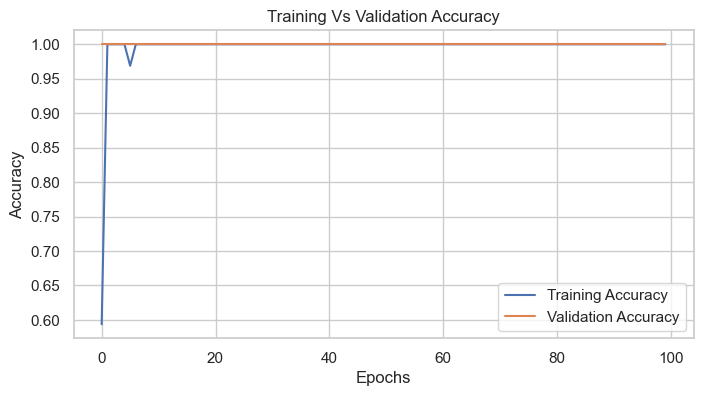

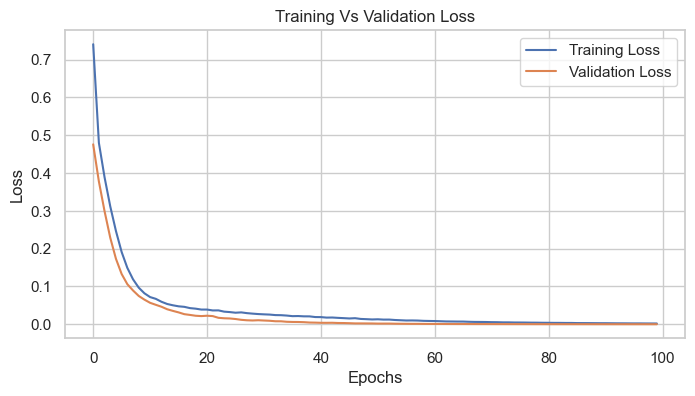

In [21]:
# Step 10 : Plot training history 

# Plot accuracy graph 
plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"] , label = "Training Accuracy")
plt.plot(history.history["val_accuracy"] , label = "Validation Accuracy")
plt.title("Training Vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("images/Training vs Validation Accuracy")
plt.show()

# Plot loss graph 
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"] , label = "Training Loss")
plt.plot(history.history["val_loss"] , label = "Validation Loss")
plt.title("Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("images/Training Vs Validation Loss")
plt.show()

In [22]:
# Step 11 : Model Prediction 

# Predict probabilities on test data 
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities into 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step



Model Accuracy :  1.0

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         6

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



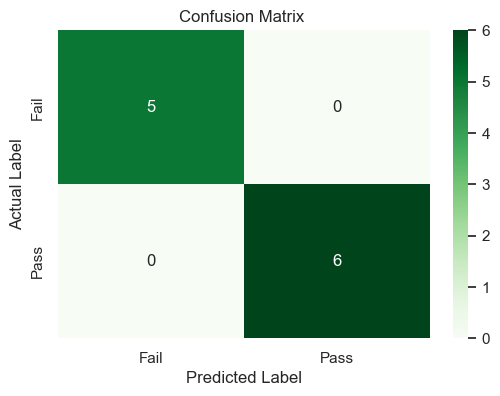

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Step 12 : Model Evaluation 

# Calculate accuracy 
accuracy = accuracy_score(y_test , y_pred)

# Print accuracy 
print("\nModel Accuracy : " , accuracy)

# Print classification report 
print("\nClassification Report : ")
print(classification_report(y_test , y_pred))

# Create confusion metrix 
cm = confusion_matrix(y_test , y_pred)

# Plot confusion matrix 
plt.figure(figsize=(6,4))
sns.heatmap(cm , annot= True , fmt="d" , cmap="Greens" , 
            xticklabels=["Fail" , "Pass"] , 
            yticklabels=["Fail" , "Pass"])
plt.title("Confusion Matrix ")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig("images/Confusion Matrix.png")
plt.show()

In [24]:
# Step 13 : Comapare actual Vs Predicted 

# Create result dataframe 
result_df = X_test.copy()

# Add actual and predicted columns 
result_df["Actual_Result"] = y_test.values
result_df["Predicted_Result"] = y_pred.flatten()
result_df["Prediction_Probability"] = y_pred_prob.flatten()

# Print results 
print("\nActual Vs Predicted Results : ")
print(result_df)


Actual Vs Predicted Results : 
    Hours_Studied  Previous_Score  Actual_Result  Predicted_Result  \
20            6.0              63              1                 1   
18            4.0              52              0                 0   
49            7.2              68              1                 1   
6             5.0              55              0                 0   
28            4.0              47              0                 0   
43            1.8              34              0                 0   
51            9.2              77              1                 1   
22            8.0              74              1                 1   
32            8.0              69              1                 1   
40            7.8              71              1                 1   
7             4.5              58              0                 0   

    Prediction_Probability  
20            9.998392e-01  
18            8.253938e-07  
49            9.999987e-01  
6          

In [25]:
# Step 14 : Test model on new custom input 

# Example new student data 
new_student = pd.DataFrame({
    "Hours_Studied":[6.5],
    "Previous_Score":[64]
})

#Scale new student data 
new_student_scaled = scaler.transform(new_student)

# Predict pass probability
new_pred_prob = model.predict(new_student_scaled)

# convert probability to class 
new_pred = (new_pred_prob > 0.5).astype(int)

# Print prediction
print("\nNew Student Prediction Probability : " , new_pred_prob[0][0])

if new_pred[0][0] == 1 :
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

New Student Prediction Probability :  0.99995524
Prediction : PASS


#### Conclusion

- Built a Neural Network model for student performance prediction  
- Identified key drivers: Study Hours & Previous Score  
- Achieved strong classification performance  
- Validated model using test data  

This project demonstrates both **Deep Learning modeling** and **real-world educational application**
